# ANALYSER DES DONNÉES DES VOITURES

Importation des  bibliothèque et Charger les données depuis un fichier CSV sur une DataFrame 

In [187]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df=pd.read_csv('../../cleaned_data/cars_data_cleaned.csv')

Statistiques descriptives numériques :

In [189]:
df.describe(include='all')

,marque,modele,annee-modele,kilometrage,type_de_carburant,puissance_fiscale,boite_de_vitesses,nombre_de_portes,origine,premiere_main,etat,airbags,climatisation,abs,esp,cd/mp3/bluetooth,prix
count,22262,22262,22262.000000,22262.000000,22262,22262.000000,22262,22262.000000,22262,22262.000000,22262,22262.000000,22262.000000,22262.000000,22262.000000,22262.000000,22262.000000
unique,23,327,NaN,NaN,4,NaN,2,NaN,4,NaN,6,NaN,NaN,NaN,NaN,NaN,NaN
top,renault,kangoo,NaN,NaN,diesel,NaN,manuelle,NaN,ww au maroc,NaN,excellent,NaN,NaN,NaN,NaN,NaN,NaN
freq,3289,1201,NaN,NaN,20239,NaN,19380,NaN,18077,NaN,13393,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2011.426332,136433.833438,NaN,7.074611,NaN,4.919055,NaN,0.255053,NaN,0.566436,0.593208,0.523358,0.349474,0.516575,103520.286093
std,NaN,NaN,5.408379,90916.268081,NaN,1.514868,NaN,0.394138,NaN,0.435901,NaN,0.495578,0.491246,0.499465,0.476815,0.499736,35144.986462
min,NaN,NaN,1990.000000,2500.000000,NaN,5.000000,NaN,3.000000,NaN,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,60000.000000
25%,NaN,NaN,2008.000000,62500.000000,NaN,6.000000,NaN,5.000000,NaN,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,75000.000000
50%,NaN,NaN,2012.000000,135000.000000,NaN,6.000000,NaN,5.000000,NaN,0.000000,NaN,1.000000,1.000000,1.000000,0.000000,1.000000,95000.000000
75%,NaN,NaN,2016.000000,195000.000000,NaN,8.000000,NaN,5.000000,NaN,1.000000,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,125000.000000


Statistiques descriptives pour les colonnes catégoriques :

In [191]:
df.describe(include=['object'])

,marque,modele,type_de_carburant,boite_de_vitesses,origine,etat
count,22262,22262,22262,22262,22262,22262
unique,23,327,4,2,4,6
top,renault,kangoo,diesel,manuelle,ww au maroc,excellent
freq,3289,1201,20239,19380,18077,13393


Valeurs manquantes (totales et pourcentages) :

In [193]:
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_summary = pd.DataFrame({
    "Valeurs Manquantes": missing_values,
    "Pourcentage (%)": missing_percent
})
print(missing_summary)

                   Valeurs Manquantes  Pourcentage (%)
marque                              0              0.0
modele                              0              0.0
annee-modele                        0              0.0
kilometrage                         0              0.0
type_de_carburant                   0              0.0
puissance_fiscale                   0              0.0
boite_de_vitesses                   0              0.0
nombre_de_portes                    0              0.0
origine                             0              0.0
premiere_main                       0              0.0
etat                                0              0.0
airbags                             0              0.0
climatisation                       0              0.0
abs                                 0              0.0
esp                                 0              0.0
cd/mp3/bluetooth                    0              0.0
prix                                0              0.0


Distribution des données catégoriques :

In [195]:
for col in df.select_dtypes(include=['object']).columns:
    print(f"\nDistribution pour {col} :")
    print(df[col].value_counts())


Distribution pour marque :
marque
renault          3289
dacia            2979
volkswagen       2925
peugeot          1896
ford             1572
mercedes-benz    1531
hyundai          1479
citroen          1150
fiat             1046
toyota            851
opel              569
nissan            471
kia               461
audi              418
bmw               393
skoda             347
seat              303
alfa romeo        118
jeep              112
land rover         96
chevrolet          88
suzuki             84
mini               84
Name: count, dtype: int64

Distribution pour modele :
modele
kangoo        1201
logan         1116
clio           843
dokker         675
220            612
              ... 
c3 picasso       3
crafter          3
s3               3
azera            3
507              3
Name: count, Length: 327, dtype: int64

Distribution pour type_de_carburant :
type_de_carburant
diesel        20239
essence        2005
hybride           9
electrique        9
Name: count, 

Analyse des valeurs aberrantes :

In [197]:
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col} : {len(outliers)} valeurs aberrantes détectées.")

annee-modele : 251 valeurs aberrantes détectées.
kilometrage : 190 valeurs aberrantes détectées.
puissance_fiscale : 585 valeurs aberrantes détectées.
nombre_de_portes : 901 valeurs aberrantes détectées.
premiere_main : 0 valeurs aberrantes détectées.
airbags : 0 valeurs aberrantes détectées.
climatisation : 0 valeurs aberrantes détectées.
abs : 0 valeurs aberrantes détectées.
esp : 0 valeurs aberrantes détectées.
cd/mp3/bluetooth : 0 valeurs aberrantes détectées.
prix : 0 valeurs aberrantes détectées.


histograme de la Distribution du Prix

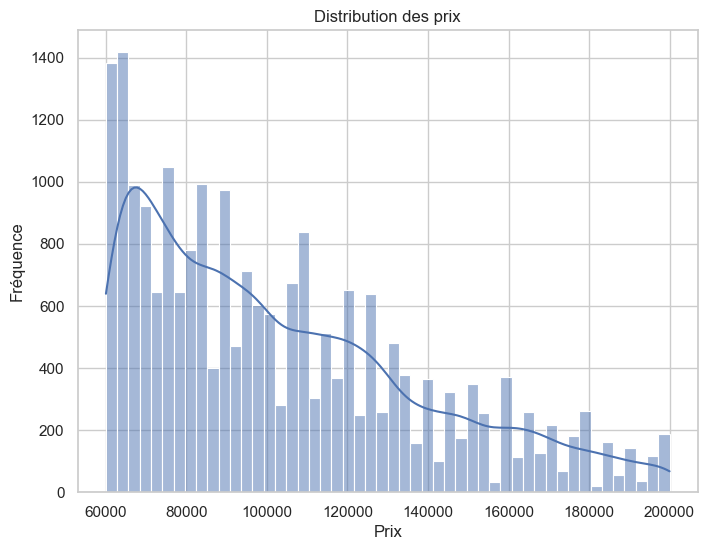

In [199]:
sns.set_theme(style="whitegrid")

# 1. Price Distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['prix'], kde=True, bins=50)
plt.title("Distribution des prix")
plt.xlabel("Prix")
plt.ylabel("Fréquence")
plt.show()

Relation entre le kilométrage et le prix moyen

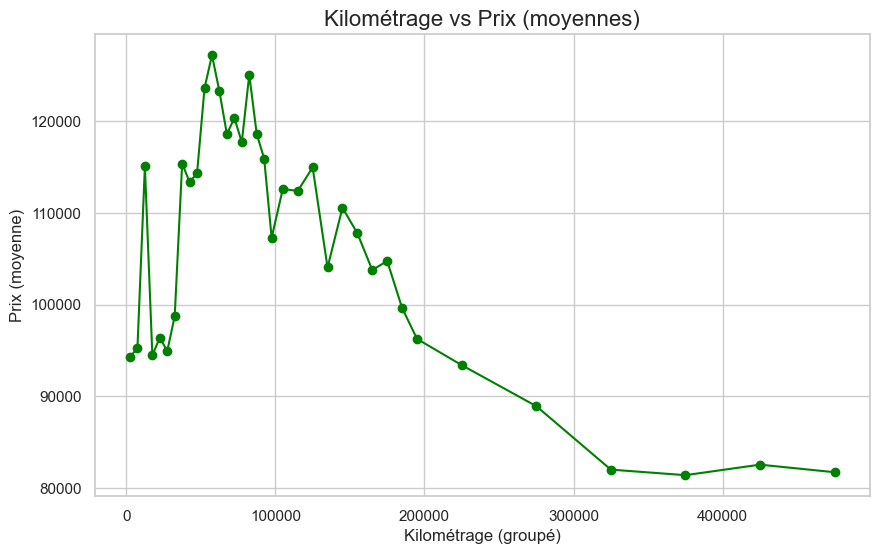

In [201]:
moyennes = df.groupby('kilometrage')['prix'].mean().reset_index()

# Tracer les données regroupées
plt.figure(figsize=(10, 6))
plt.plot(moyennes['kilometrage'], moyennes['prix'], marker='o', color='green')
plt.title('Kilométrage vs Prix (moyennes)', fontsize=16)
plt.xlabel('Kilométrage (groupé)')
plt.ylabel('Prix (moyenne)')
plt.show()


Distribution du Prix par Année de Modèle

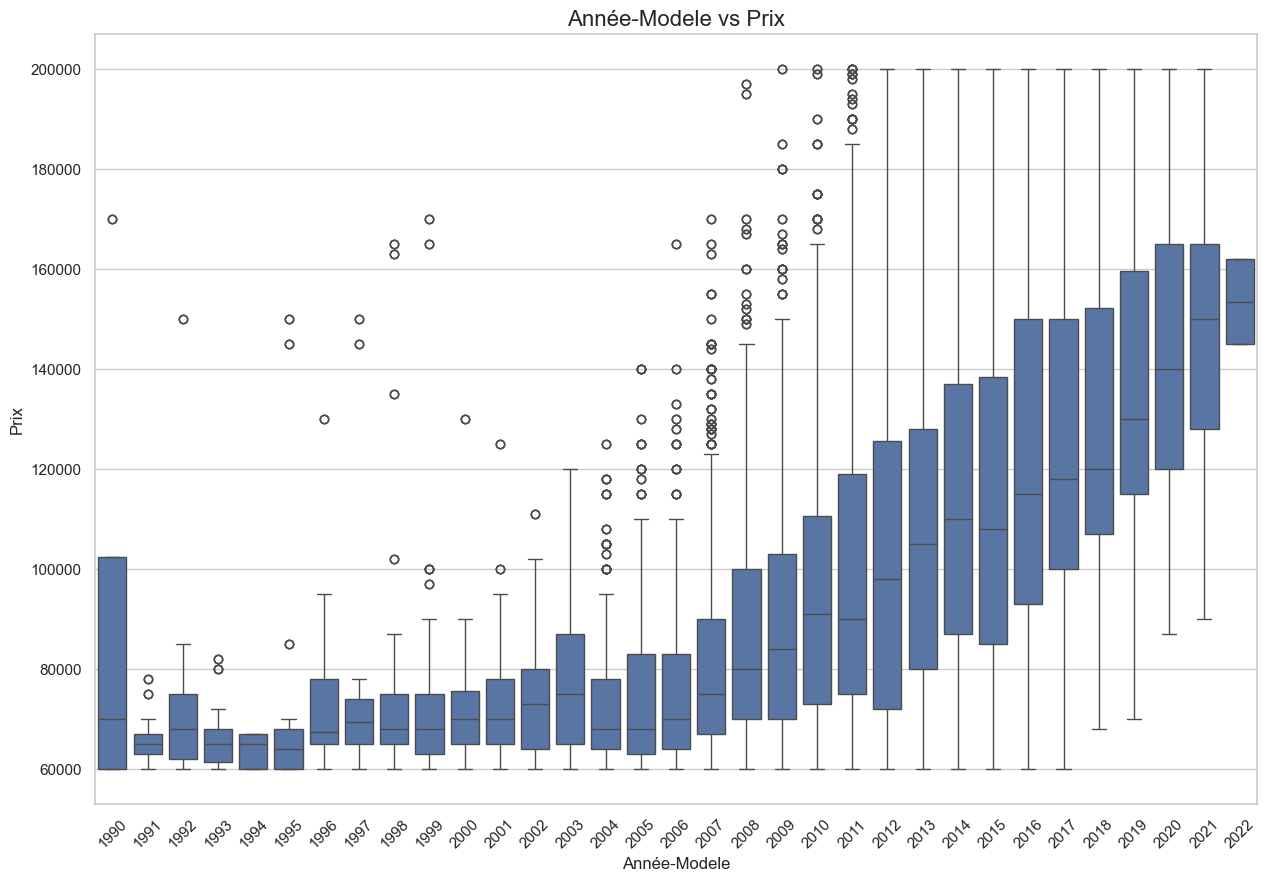

In [203]:
plt.figure(figsize=(15, 10))
sns.boxplot(x=df['annee-modele'], y=df['prix'])
plt.title('Année-Modele vs Prix', fontsize=16)
plt.xticks(rotation=45)
plt.xlabel('Année-Modele')
plt.ylabel('Prix')
plt.show()


Top 10 des Marques par Nombre de Véhicules

C:\Users\HP\AppData\Local\Temp\ipykernel_17004\793698646.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.index, y=top_brands.values, palette="viridis")


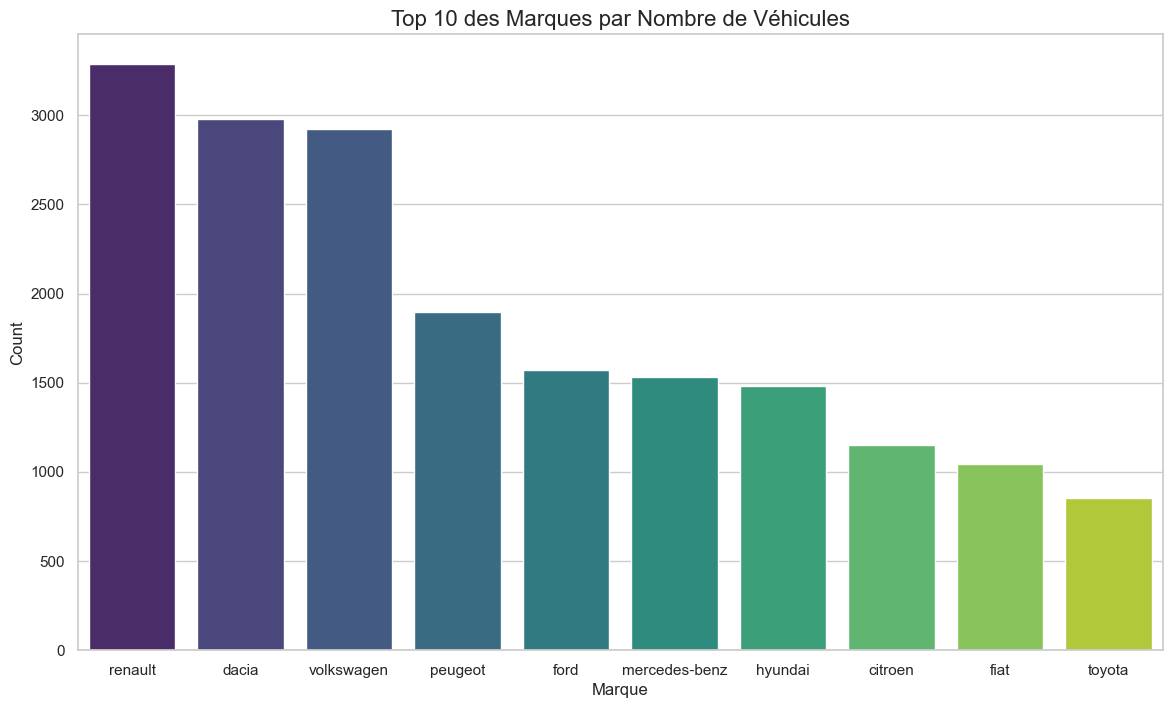

In [205]:
plt.figure(figsize=(14, 8))
top_brands = df['marque'].value_counts().head(10)
sns.barplot(x=top_brands.index, y=top_brands.values, palette="viridis")
plt.title('Top 10 des Marques par Nombre de Véhicules', fontsize=16)
plt.xlabel('Marque')
plt.ylabel('Count')
plt.show()

Distribution des Prix selon le Type de Carburant

C:\Users\HP\AppData\Local\Temp\ipykernel_17004\1591795793.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['type_de_carburant'], y=df['prix'], palette="muted")


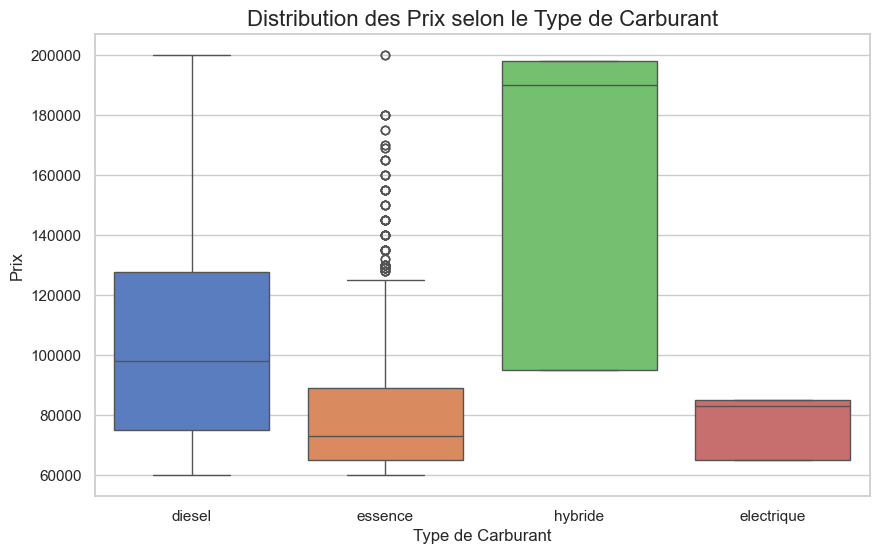

In [207]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['type_de_carburant'], y=df['prix'], palette="muted")
plt.title('Distribution des Prix selon le Type de Carburant', fontsize=16)
plt.xlabel('Type de Carburant')
plt.ylabel('Prix')
plt.show()

Répartition des Voitures par Type de Carburant

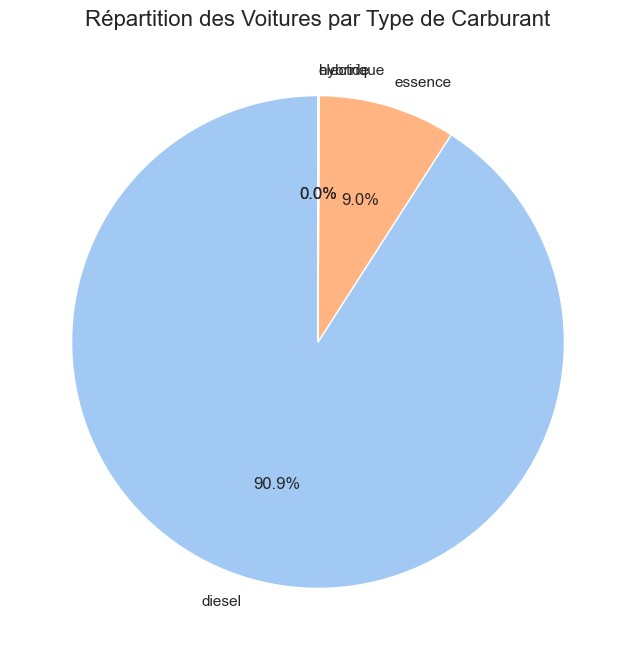

In [209]:
# Group by Type de carburant and calculate the counts
fuel_type_counts = df['type_de_carburant'].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    fuel_type_counts.values, 
    labels=fuel_type_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=sns.color_palette("pastel")
)
plt.title('Répartition des Voitures par Type de Carburant', fontsize=16)
plt.show()

Répartition des Voitures par Origine

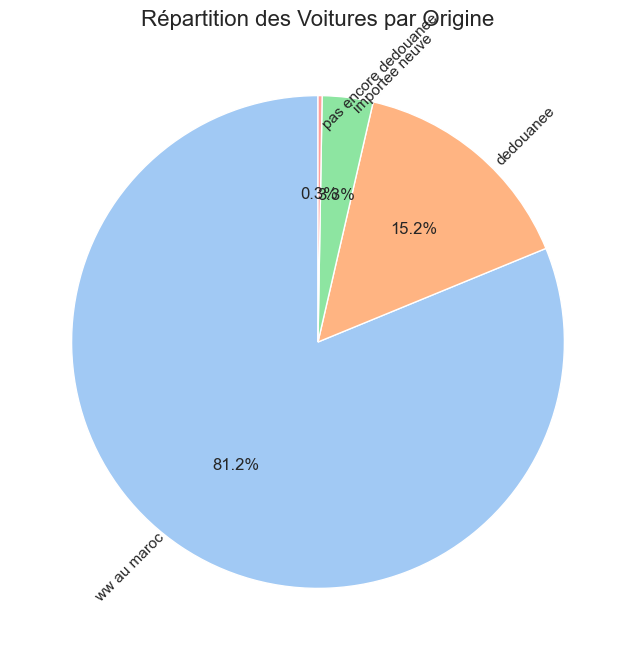

In [211]:
# Group by Origine and calculate the counts
origine_counts = df['origine'].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
wedges, texts, autotexts =plt.pie(
    origine_counts.values, 
    labels=origine_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=sns.color_palette("pastel")
)

for text in texts:
    text.set_rotation(45)
    
plt.title('Répartition des Voitures par Origine', fontsize=16)
plt.show()

Carte de Corrélation des Caractéristiques Numériques

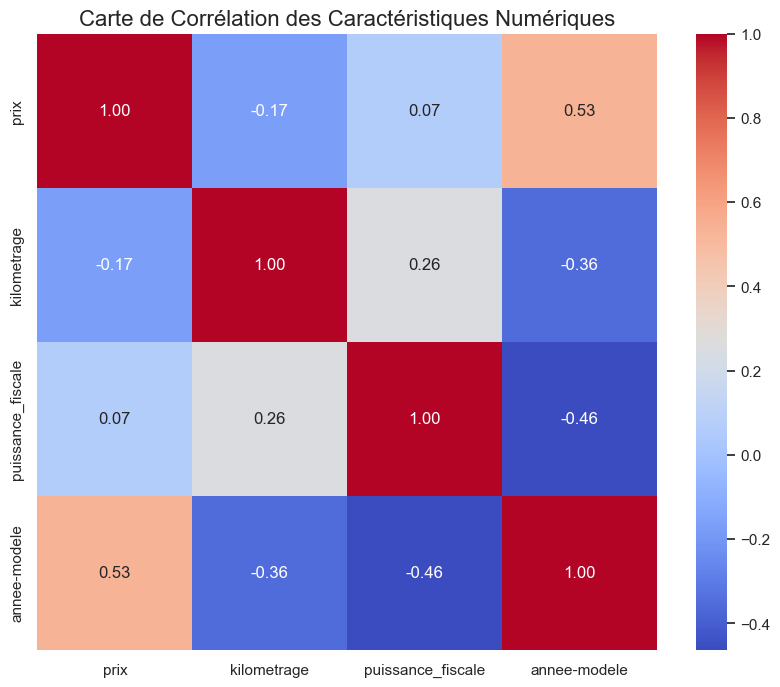

In [213]:
plt.figure(figsize=(10, 8))
numerical_features = ['prix', 'kilometrage', 'puissance_fiscale', 'annee-modele']
correlation_matrix = df[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Carte de Corrélation des Caractéristiques Numériques', fontsize=16)
plt.show()


Distribution des Prix selon la Boîte de Vitesses

C:\Users\HP\AppData\Local\Temp\ipykernel_17004\2003698813.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['boite_de_vitesses'], y=df['prix'], palette='muted')


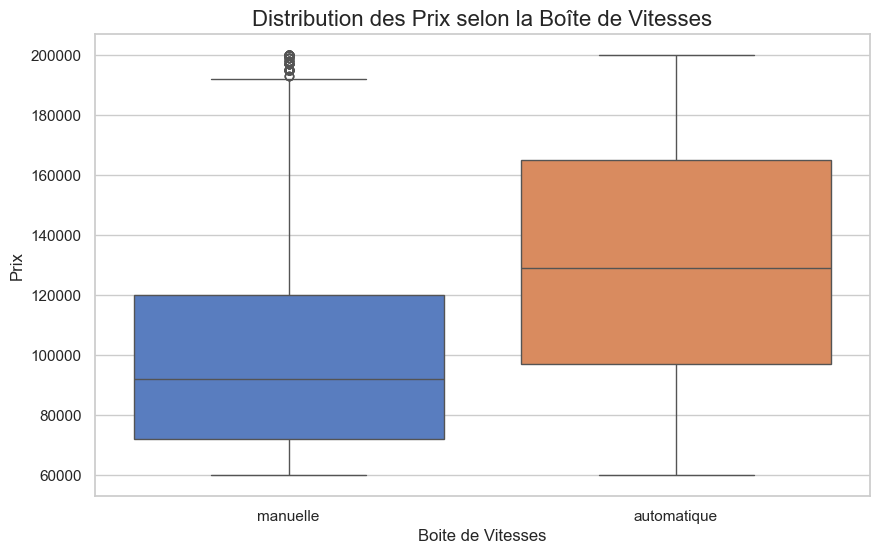

In [215]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['boite_de_vitesses'], y=df['prix'], palette='muted')
plt.title('Distribution des Prix selon la Boîte de Vitesses', fontsize=16)
plt.xlabel('Boite de Vitesses')
plt.ylabel('Prix')
plt.show()


Prix Moyen par les 10 Principales Marques

C:\Users\HP\AppData\Local\Temp\ipykernel_17004\1124787929.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands_avg_price.index, y=top_brands_avg_price.values, palette='viridis')


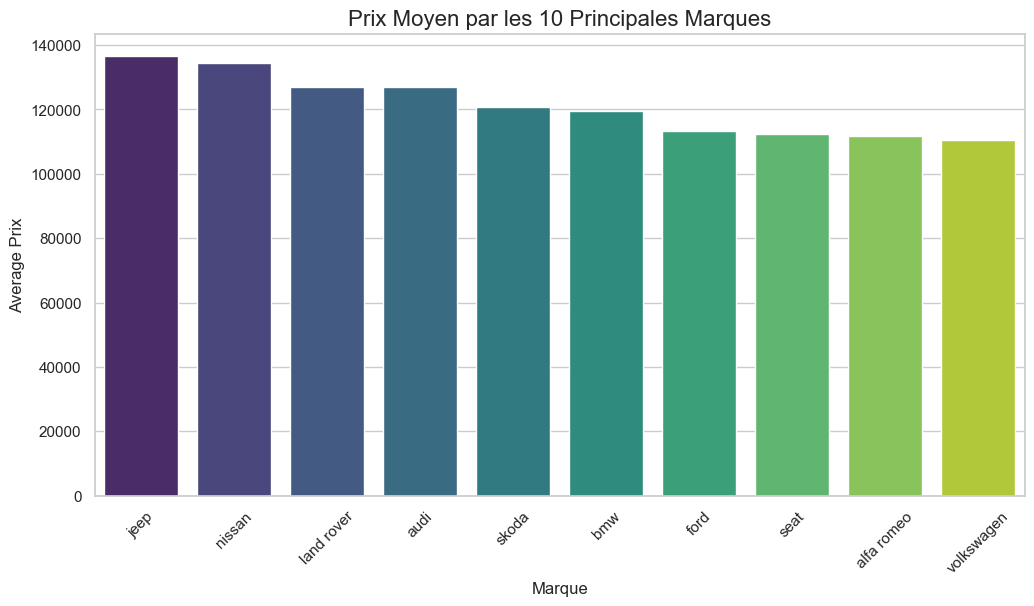

In [217]:
top_brands_avg_price = df.groupby('marque')['prix'].mean().nlargest(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_brands_avg_price.index, y=top_brands_avg_price.values, palette='viridis')
plt.title('Prix Moyen par les 10 Principales Marques', fontsize=16)
plt.xlabel('Marque')
plt.ylabel('Average Prix')
plt.xticks(rotation=45)
plt.show()


Voir les statistiques de la DataFrame

In [219]:
# Display descriptive statistics for numerical features
df.describe()

,annee-modele,kilometrage,puissance_fiscale,nombre_de_portes,premiere_main,airbags,climatisation,abs,esp,cd/mp3/bluetooth,prix
count,22262.000000,22262.000000,22262.000000,22262.000000,22262.000000,22262.000000,22262.000000,22262.000000,22262.000000,22262.000000,22262.000000
mean,2011.426332,136433.833438,7.074611,4.919055,0.255053,0.566436,0.593208,0.523358,0.349474,0.516575,103520.286093
std,5.408379,90916.268081,1.514868,0.394138,0.435901,0.495578,0.491246,0.499465,0.476815,0.499736,35144.986462
min,1990.000000,2500.000000,5.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,60000.000000
25%,2008.000000,62500.000000,6.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,75000.000000
50%,2012.000000,135000.000000,6.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,95000.000000
75%,2016.000000,195000.000000,8.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,125000.000000
max,2022.000000,475000.000000,14.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,200000.000000


Détection des Valeurs Abérantes pour le Prix

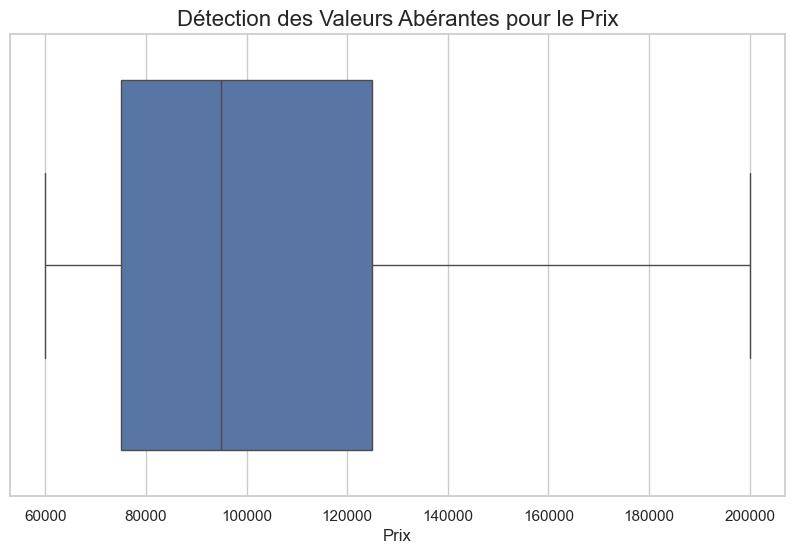

In [221]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['prix'])
plt.title('Détection des Valeurs Abérantes pour le Prix', fontsize=16)
plt.xlabel('Prix')
plt.show()


Répartition des Véhicules par État

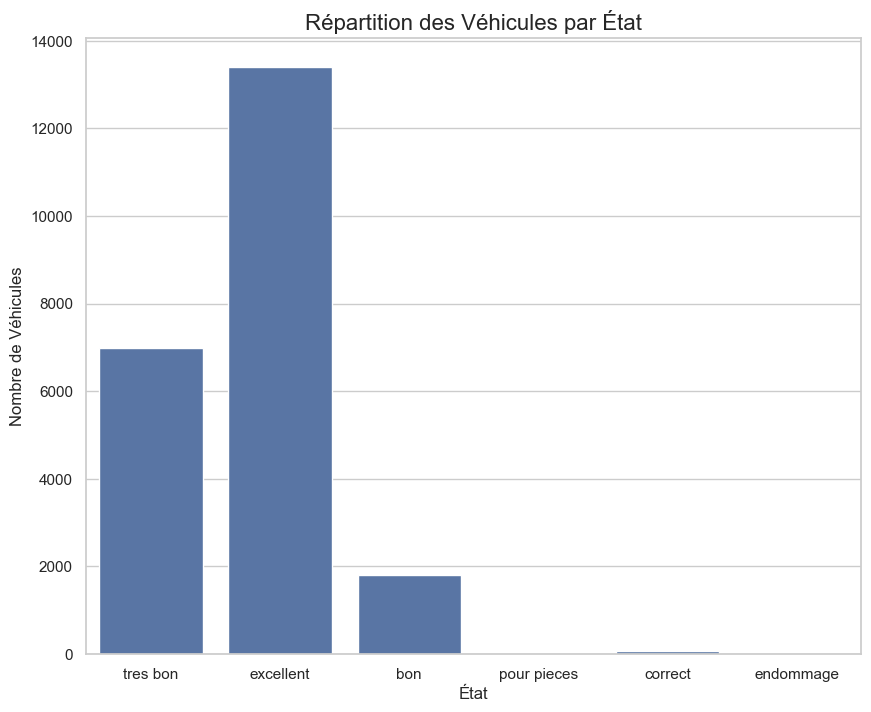

In [223]:
plt.figure(figsize=(10, 8))
sns.countplot(data=df, x='etat')
plt.title('Répartition des Véhicules par État', fontsize=16)
plt.xlabel('État')
plt.ylabel('Nombre de Véhicules')
plt.show()
